__Markus Mulvihill__

__Last updated May 2026__

# Necessary Packages and Modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tomllib

# Introduction

This file examines the accuracy and time complexity of the extended Kalman filter and the particle filter with various number of particles.

In [2]:
try:
    time_arr_03 = np.load("../scripts/variables/time_arr_03.npy")
    error_arr_03 = np.load("../scripts/variables/error_arr_03.npy")
    print("Loaded variables")
except Exception:
    print("Run 03_Estimator3Comparison.py")

Loaded variables


In [3]:
with open("../config.toml", "rb") as f:
    cfg = tomllib.load(f)
curr_module = "03"
num_particles = cfg[curr_module]["num_particles"]
low_perc = cfg[curr_module]["low_perc"]
high_perc = cfg[curr_module]["high_perc"]
CI = cfg[curr_module]["CI"]
converge_time = cfg[curr_module]["converge_time"]
deviations = cfg[curr_module]["deviations"]
dev_perc = cfg[curr_module]["dev_perc"]
num_deviations = len(deviations)

# Plot Results

<Axes: xlabel='Estimator', ylabel='Time to run (s)'>

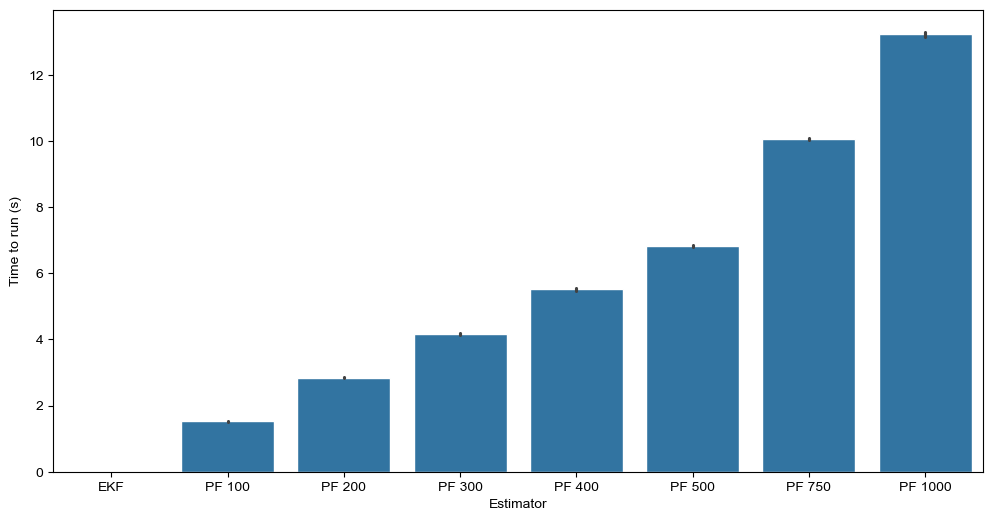

In [4]:
mean_time_run = np.average(time_arr_03[0, :, :].T, axis=0)
filters = ["EKF"]
pfs = [f"PF {particles}" for particles in num_particles]
filters.extend(pfs)
df = pd.DataFrame(time_arr_03[0, :, :].T, columns=filters).melt(
    var_name="Estimator", value_name="Time to run (s)"
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.set_style("whitegrid")
sns.barplot(df, x="Estimator", y="Time to run (s)", ax=ax)

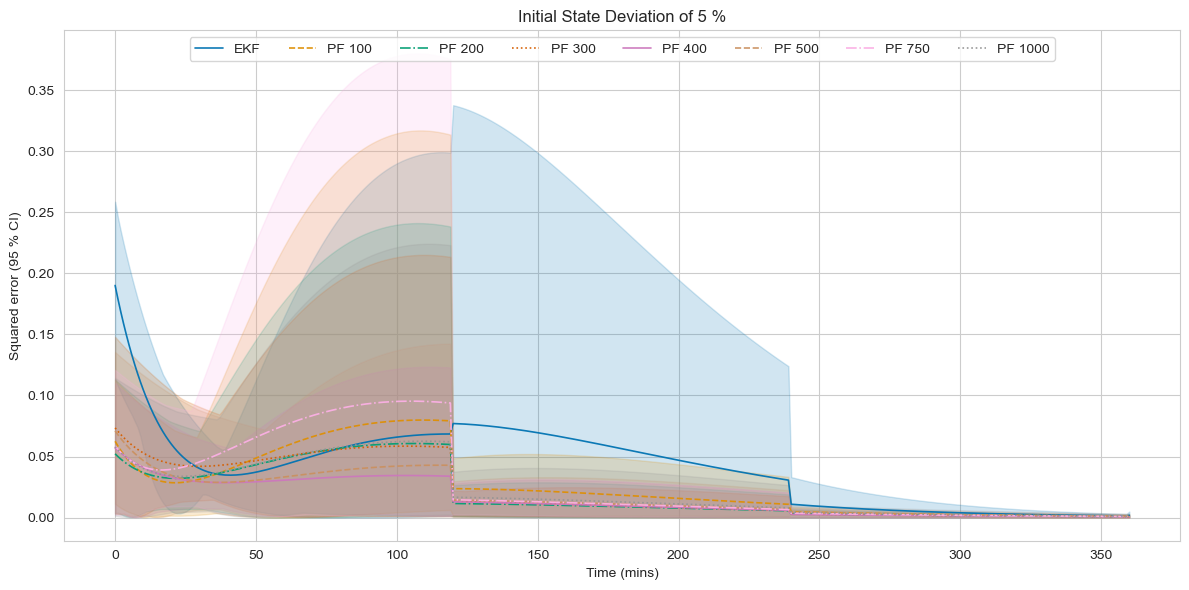

In [5]:
for j in range(num_deviations):
    mean_err = np.mean(error_arr_03[j, :, :], axis=1)
    ci_low = np.percentile(error_arr_03[j, :, :], low_perc, axis=1)
    ci_high = np.percentile(error_arr_03[j, :, :], high_perc, axis=1)
    time = np.arange(mean_err.shape[1])
    num_plots = len(filters)  # 5 per subplot
    num_filters = len(filters)
    palette = sns.color_palette("colorblind", num_filters)

    # fig, ax = plt.subplots(2,1, sharex='col', sharey=True, figsize=(12,5))
    fig, ax = plt.subplots(figsize=(12, 6))

    for i in range(num_plots):
        ax.plot(
            time,
            mean_err[i],
            color=palette[i],
            linewidth=1.2,
            alpha=0.95,
            linestyle=["-", "--", "-.", ":"][i % 4],
            label=f"{filters[i]}",
        )
        ax.fill_between(time, ci_low[i], ci_high[i], color=palette[i], alpha=0.18)
    ax.set_ylabel(f"Squared error ({CI} % CI)")
    ax.legend(loc="upper center", ncols=num_plots)
    ax.set_xlabel("Time (mins)")
    ax.set_title(f"Initial State Deviation of {dev_perc[j]} %")

    fig.tight_layout()

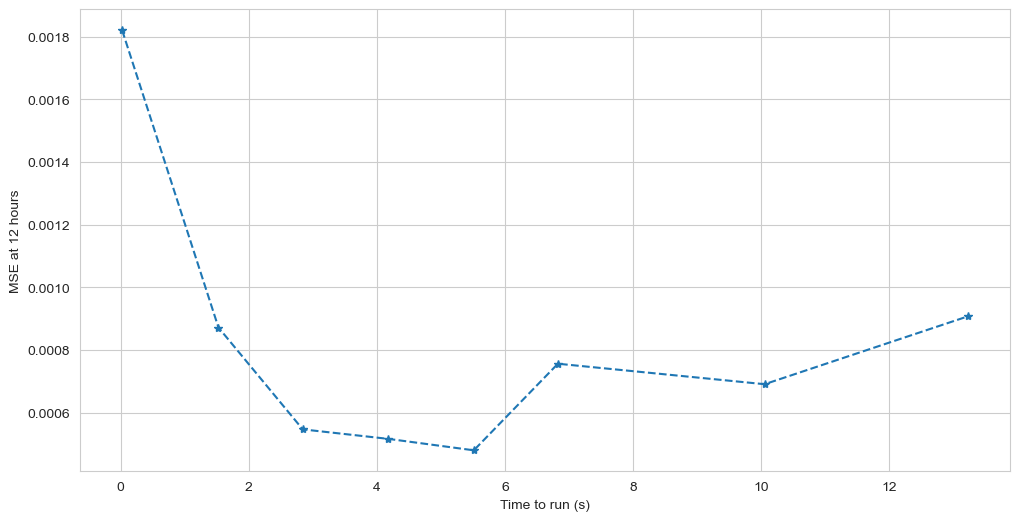

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(mean_time_run, mean_err[:, -1], linestyle="--", marker="*")
ax.set_xlabel("Time to run (s)")
ax.set_ylabel("MSE at 12 hours");

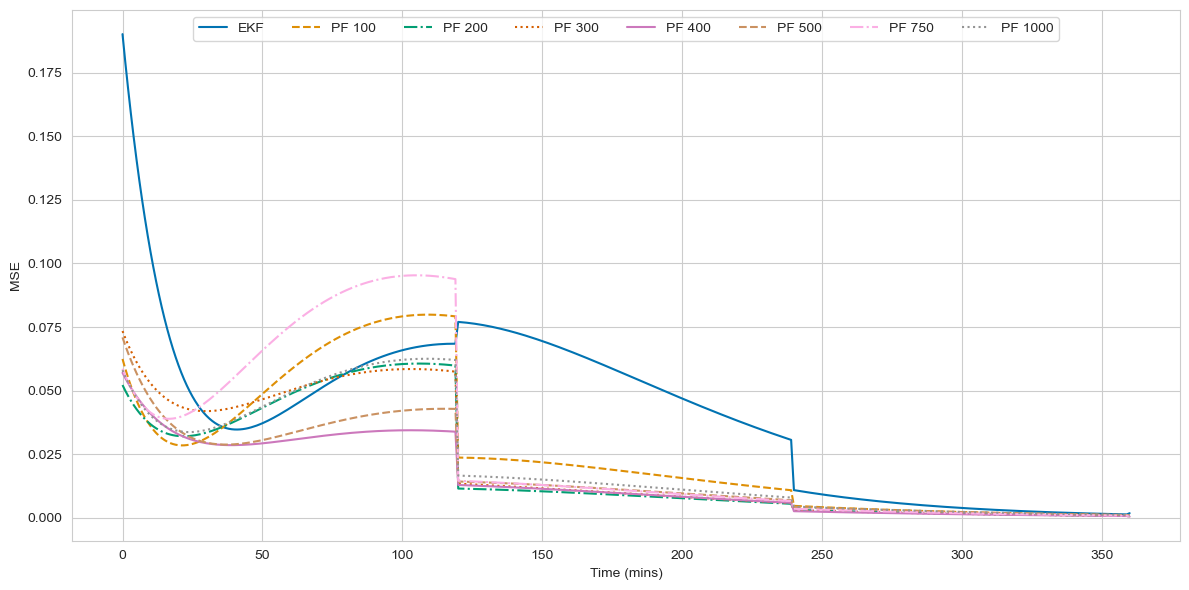

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

for i in range(num_filters):
    ax.plot(
        time[:converge_time],
        mean_err[i, :converge_time],
        color=palette[i],
        linestyle=["-", "--", "-.", ":"][i % 4],
        label=filters[i],
    )
ax.set_xlabel("Time (mins)")
ax.set_ylabel("MSE")
ax.legend(ncols=num_plots, loc="upper center")
fig.tight_layout()